(101766, 49)
readmitted
No     54864
Yes    46902
Name: count, dtype: int64
Index(['encounter_id', 'patient_nbr', 'race', 'gender', 'age',
       'admission_type_id', 'discharge_disposition_id', 'admission_source_id',
       'time_in_hospital', 'payer_code', 'medical_specialty',
       'num_lab_procedures', 'num_procedures', 'num_medications',
       'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1',
       'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult',
       'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
       'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
       'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
       'tolazamide', 'examide', 'citoglipton', 'insulin',
       'glyburide-metformin', 'glipizide-metformin',
       'glimepiride-pioglitazone', 'metformin-rosiglitazone',
       'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted'],
      dtype='object')
Ind

/var/folders/tf/d4xms4w14_b7p416gw5f8w4r0000gn/T/ipykernel_81194/126926053.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='readmitted', data=df, palette='pastel')


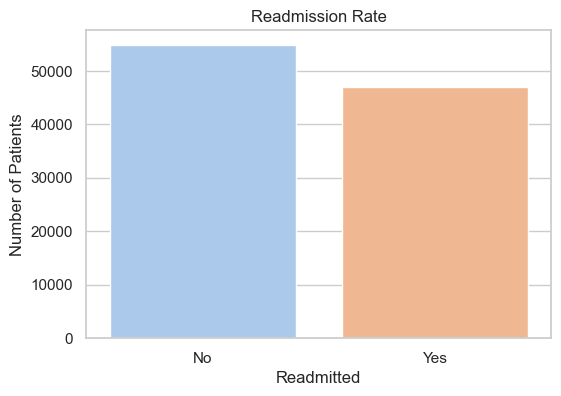

/var/folders/tf/d4xms4w14_b7p416gw5f8w4r0000gn/T/ipykernel_81194/126926053.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age', data=df, palette='muted')


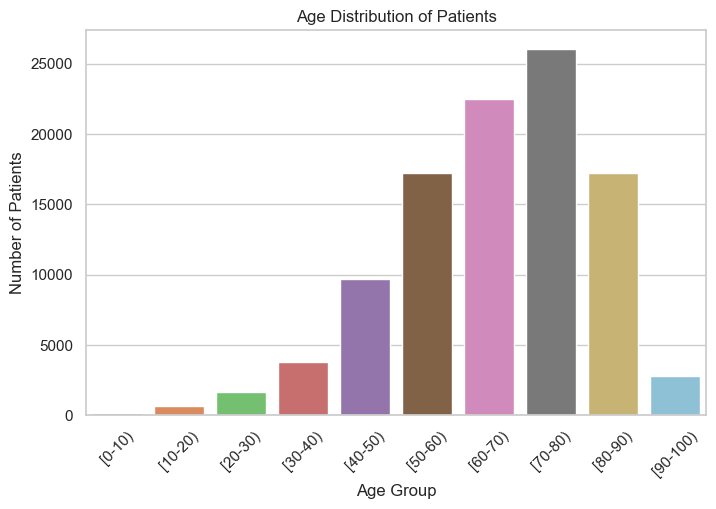

/var/folders/tf/d4xms4w14_b7p416gw5f8w4r0000gn/T/ipykernel_81194/126926053.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_diag1.values, y=top_diag1.index, palette='coolwarm')


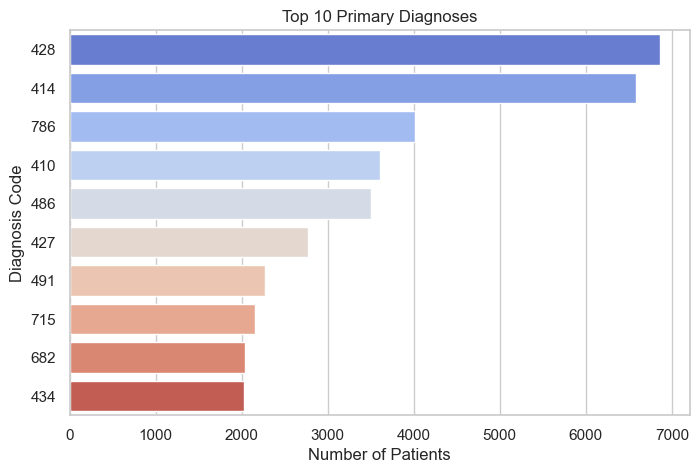

In [38]:
#Cleaned data from a real healthcare dataset
#Import the library function
import pandas as pd

# Load data
df = pd.read_csv('../data/diabetic_data.csv')

# Drop weight column
df.drop('weight', axis=1, inplace=True)

# Simplify readmitted column
df['readmitted'] = df['readmitted'].replace({'>30': 'Yes', '<30': 'Yes', 'NO': 'No'})

# Confirm changes
print(df.shape)
print(df['readmitted'].value_counts())
print(df.columns)
df
df.isnull().sum()
df.isnull().values.any()
# Only show columns with missing values
missing_cols = df.columns[df.isnull().any()]
print(missing_cols)
# Fill missing 'max_glu_serum' and 'A1Cresult' with 'None'
df['max_glu_serum'] = df['max_glu_serum'].replace('?', 'None')
df['A1Cresult'] = df['A1Cresult'].replace('?', 'None')

import matplotlib.pyplot as plt
import seaborn as sns

# Set nice style for plots
sns.set(style="whitegrid")

# 1. Overall info
print(df.info())

# 2. Basic statistics
print(df.describe(include='all'))

# 3. Readmission rate plot
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df, palette='pastel')
plt.title('Readmission Rate')
plt.xlabel('Readmitted')
plt.ylabel('Number of Patients')
plt.show()

# 4. Age distribution
plt.figure(figsize=(8,5))
sns.countplot(x='age', data=df, palette='muted')
plt.title('Age Distribution of Patients')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.xticks(rotation=45)
plt.show()

# 5. Top 10 Diagnosis Codes
top_diag1 = df['diag_1'].value_counts().head(10)

plt.figure(figsize=(8,5))
sns.barplot(x=top_diag1.values, y=top_diag1.index, palette='coolwarm')
plt.title('Top 10 Primary Diagnoses')
plt.xlabel('Number of Patients')
plt.ylabel('Diagnosis Code')
plt.show()







In [24]:
#Logistic Regression Machine Learning Model
# Import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select Features (Simple version first)
features = ['time_in_hospital', 'num_lab_procedures', 'num_medications', 
            'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']

X = df[features]
y = df['readmitted'].map({'Yes': 1, 'No': 0})   # Convert to 1/0 for model

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Build model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.6180150671470684

Classification Report:
               precision    recall  f1-score   support

           0       0.61      0.81      0.70     16461
           1       0.64      0.39      0.49     14069

    accuracy                           0.62     30530
   macro avg       0.62      0.60      0.59     30530
weighted avg       0.62      0.62      0.60     30530


Confusion Matrix:
 [[13362  3099]
 [ 8563  5506]]


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


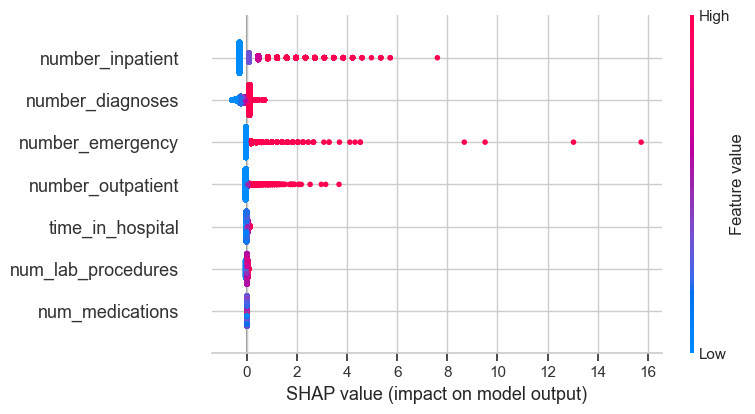

In [23]:
#SHAP AI Explainability helps you understand which features influenced a machine learning model's prediction and how much, offering clear, human-readable insights into the model's decisions.
# Import SHAP
import shap

# Initialize the JavaScript visualization code for SHAP
shap.initjs()

# Create an explainer object for your logistic regression model
explainer = shap.Explainer(model, X_test)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# 1. Summary plot - overall feature importance
shap.summary_plot(shap_values, X_test)


In [37]:
# Save the cleaned data to CSV
df.to_csv('../data/cleaned_diabetes_data.csv', index=False)
# After columns are in uppercase
columns_to_clean = ['DIAG_1', 'DIAG_2', 'DIAG_3', 'PAYER_CODE', 'MEDICAL_SPECIALTY', 'RACE']

# Replace '?' with 'Unknown' safely
for col in columns_to_clean:
    if col in df.columns:
        df[col] = df[col].replace('?', 'Unknown')

